In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
np.random.seed(42)
n = 1000

age             = np.random.randint(21, 65, n)
income          = np.random.randint(15000, 120000, n)
debt            = np.random.randint(0, 50000, n)
loan_amount     = np.random.randint(5000, 80000, n)
credit_limit    = np.random.randint(10000, 100000, n)
employed_years  = np.random.randint(0, 30, n)
num_accounts    = np.random.randint(1, 10, n)
late_payments   = np.random.randint(0, 10, n)
payment_history = np.random.randint(1, 100, n)
savings         = np.random.randint(0, 60000, n)

score = (
    (income        > 50000).astype(int) +
    (debt          < 20000).astype(int) +
    (late_payments < 3    ).astype(int) +
    (employed_years > 3   ).astype(int) +
    (savings       > 10000).astype(int)
)
Creditability = (score >= 3).astype(int)

df = pd.DataFrame({
    'age'            : age,
    'income'         : income,
    'debt'           : debt,
    'loan_amount'    : loan_amount,
    'credit_limit'   : credit_limit,
    'employed_years' : employed_years,
    'num_accounts'   : num_accounts,
    'late_payments'  : late_payments,
    'payment_history': payment_history,
    'savings'        : savings,
    'Creditability'  : Creditability
})

print("✅ Dataset created!")
print(f"Total people : {len(df)}")
print(f"Good Credit  : {sum(Creditability==1)}")
print(f"Bad Credit   : {sum(Creditability==0)}")
print(f"\nSample data:")
df.head(10)

✅ Dataset created!
Total people : 1000
Good Credit  : 721
Bad Credit   : 279

Sample data:


,age,income,debt,loan_amount,credit_limit,employed_years,num_accounts,late_payments,payment_history,savings,Creditability
0,59,19018,35046,11304,49464,22,1,1,44,49508,1
1,49,26302,47064,12345,52351,7,5,4,35,41831,0
2,35,82506,35923,34300,92534,29,3,2,55,42933,1
3,63,56157,41089,29259,23869,24,1,1,87,47307,1
4,28,69917,3814,20352,70315,5,3,0,9,48340,1
5,41,107738,45893,38365,30954,13,6,9,2,37415,1
6,59,111646,35984,24446,41555,2,7,1,61,42770,1
7,39,98122,26616,7336,73353,9,8,5,41,20802,1
8,43,39519,2113,67032,92190,2,4,7,44,43601,0
9,31,111809,43006,12521,55026,26,3,2,64,10420,1


In [3]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()

=== SHAPE ===
(1000, 11)

=== DATA TYPES ===
age                int64
income             int64
debt               int64
loan_amount        int64
credit_limit       int64
employed_years     int64
num_accounts       int64
late_payments      int64
payment_history    int64
savings            int64
Creditability      int64
dtype: object

=== MISSING VALUES ===
age                0
income             0
debt               0
loan_amount        0
credit_limit       0
employed_years     0
num_accounts       0
late_payments      0
payment_history    0
savings            0
Creditability      0
dtype: int64

=== BASIC STATISTICS ===


,age,income,debt,loan_amount,credit_limit,employed_years,num_accounts,late_payments,payment_history,savings,Creditability
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,42.515000,66956.463000,25799.920000,42071.923000,54292.1560,14.695000,5.008000,4.55600,49.577000,29870.318000,0.721000
std,12.611059,29722.842781,14171.686291,21867.108102,26195.7729,8.427039,2.587398,2.88534,28.844793,16794.522516,0.448732
min,21.000000,15060.000000,125.000000,5138.000000,10112.0000,0.000000,1.000000,0.00000,1.000000,2.000000,0.000000
25%,32.000000,41659.250000,13391.250000,23444.000000,32228.5000,8.000000,3.000000,2.00000,25.000000,15746.000000,0.000000
50%,43.000000,66415.000000,26719.500000,41229.500000,53521.0000,15.000000,5.000000,4.00000,48.000000,30207.500000,1.000000
75%,53.000000,92003.000000,37769.000000,60757.750000,76965.2500,22.000000,7.000000,7.00000,75.250000,43941.500000,1.000000
max,64.000000,119540.000000,49927.000000,79965.000000,99791.0000,29.000000,9.000000,9.00000,99.000000,59931.000000,1.000000


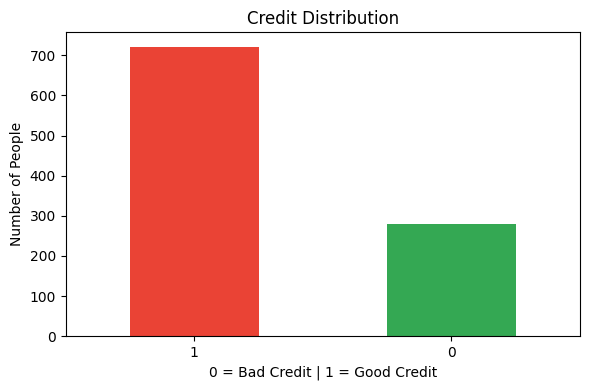

Good Credit: 721 people
Bad Credit : 279 people


In [4]:
plt.figure(figsize=(6,4))
colors = ['#ea4335','#34a853']
df['Creditability'].value_counts().plot(kind='bar', color=colors)
plt.title('Credit Distribution')
plt.xlabel('0 = Bad Credit | 1 = Good Credit')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Good Credit: {sum(df['Creditability']==1)} people")
print(f"Bad Credit : {sum(df['Creditability']==0)} people")

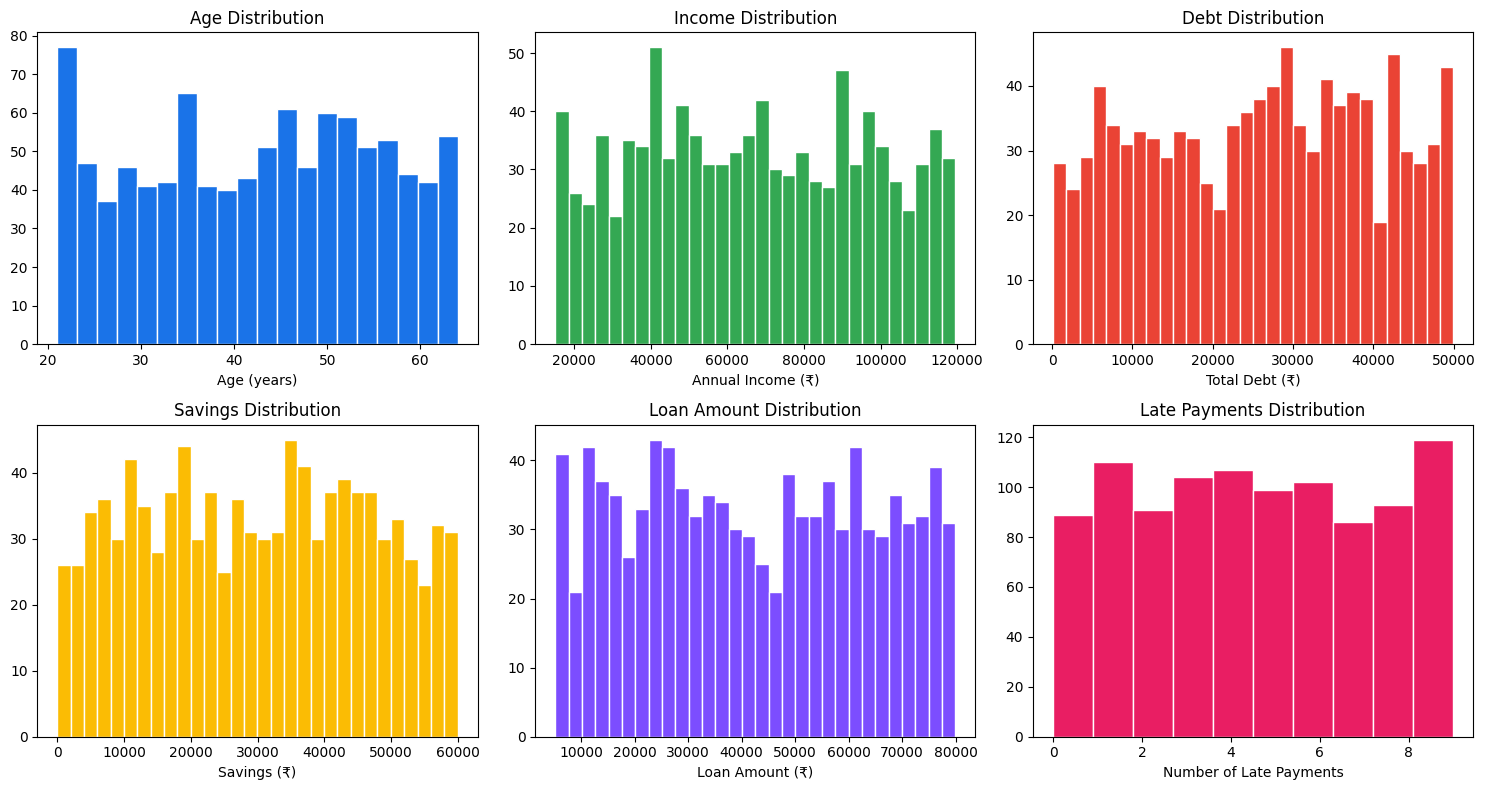

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(df['age'], bins=20,
               color='#1a73e8', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')

axes[0,1].hist(df['income'], bins=30,
               color='#34a853', edgecolor='white')
axes[0,1].set_title('Income Distribution')
axes[0,1].set_xlabel('Annual Income (₹)')

axes[0,2].hist(df['debt'], bins=30,
               color='#ea4335', edgecolor='white')
axes[0,2].set_title('Debt Distribution')
axes[0,2].set_xlabel('Total Debt (₹)')

axes[1,0].hist(df['savings'], bins=30,
               color='#fbbc04', edgecolor='white')
axes[1,0].set_title('Savings Distribution')
axes[1,0].set_xlabel('Savings (₹)')

axes[1,1].hist(df['loan_amount'], bins=30,
               color='#7c4dff', edgecolor='white')
axes[1,1].set_title('Loan Amount Distribution')
axes[1,1].set_xlabel('Loan Amount (₹)')

axes[1,2].hist(df['late_payments'], bins=10,
               color='#e91e63', edgecolor='white')
axes[1,2].set_title('Late Payments Distribution')
axes[1,2].set_xlabel('Number of Late Payments')

plt.tight_layout()
plt.show()

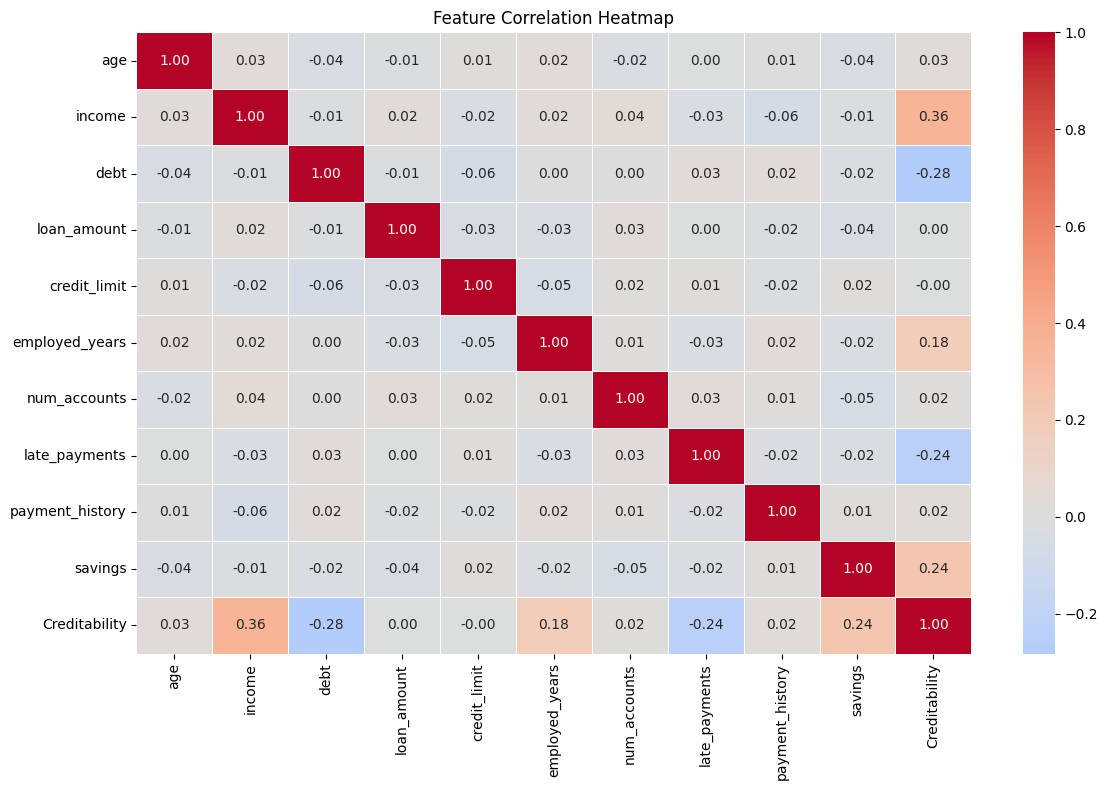

In [6]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

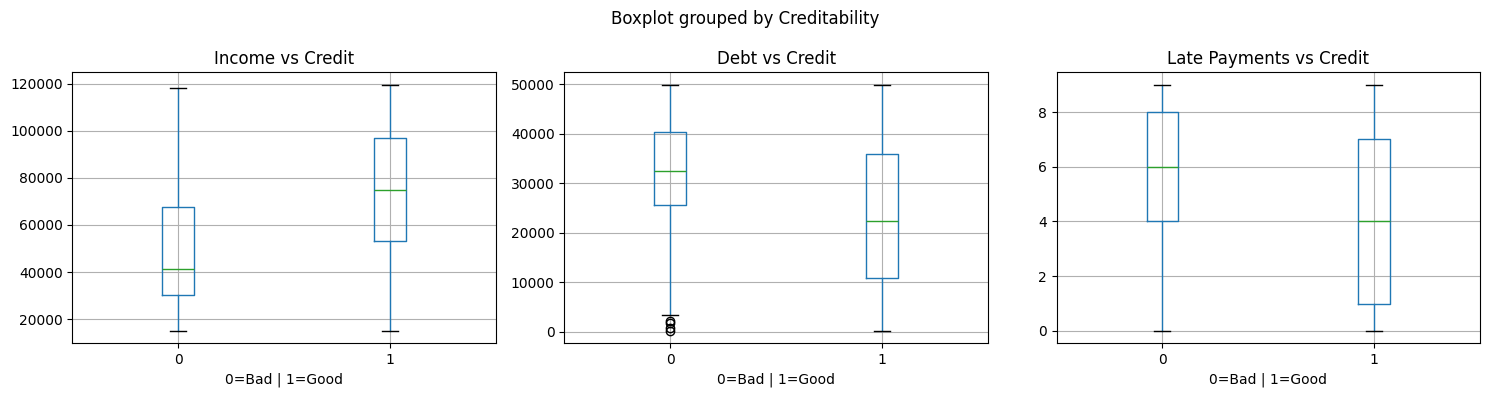

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='income',
           by='Creditability', ax=axes[0])
axes[0].set_title('Income vs Credit')
axes[0].set_xlabel('0=Bad | 1=Good')

df.boxplot(column='debt',
           by='Creditability', ax=axes[1])
axes[1].set_title('Debt vs Credit')
axes[1].set_xlabel('0=Bad | 1=Good')

df.boxplot(column='late_payments',
           by='Creditability', ax=axes[2])
axes[2].set_title('Late Payments vs Credit')
axes[2].set_xlabel('0=Bad | 1=Good')

plt.tight_layout()
plt.show()

In [8]:
X = df.drop('Creditability', axis=1)
y = df['Creditability']

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

Features (X): (1000, 10)
Target   (y): (1000,)

Feature columns:
['age', 'income', 'debt', 'loan_amount', 'credit_limit', 'employed_years', 'num_accounts', 'late_payments', 'payment_history', 'savings']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print("✅ Data split and scaled!")

Training samples : 800
Testing samples  : 200
✅ Data split and scaled!


In [10]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print("✅ Logistic Regression trained!")

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
print("✅ Decision Tree trained!")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest trained!")

✅ Logistic Regression trained!
✅ Decision Tree trained!
✅ Random Forest trained!


In [11]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model("Logistic Regression", lr, X_test, y_test)
dt_pred, dt_prob = evaluate_model("Decision Tree",       dt, X_test, y_test)
rf_pred, rf_prob = evaluate_model("Random Forest",       rf, X_test, y_test)


  Logistic Regression
  Accuracy  : 0.7600
  Precision : 0.8000
  Recall    : 0.8889
  F1-Score  : 0.8421
  ROC-AUC   : 0.8549

  Decision Tree
  Accuracy  : 0.9850
  Precision : 0.9796
  Recall    : 1.0000
  F1-Score  : 0.9897
  ROC-AUC   : 0.9732

  Random Forest
  Accuracy  : 0.9800
  Precision : 0.9730
  Recall    : 1.0000
  F1-Score  : 0.9863
  ROC-AUC   : 0.9987


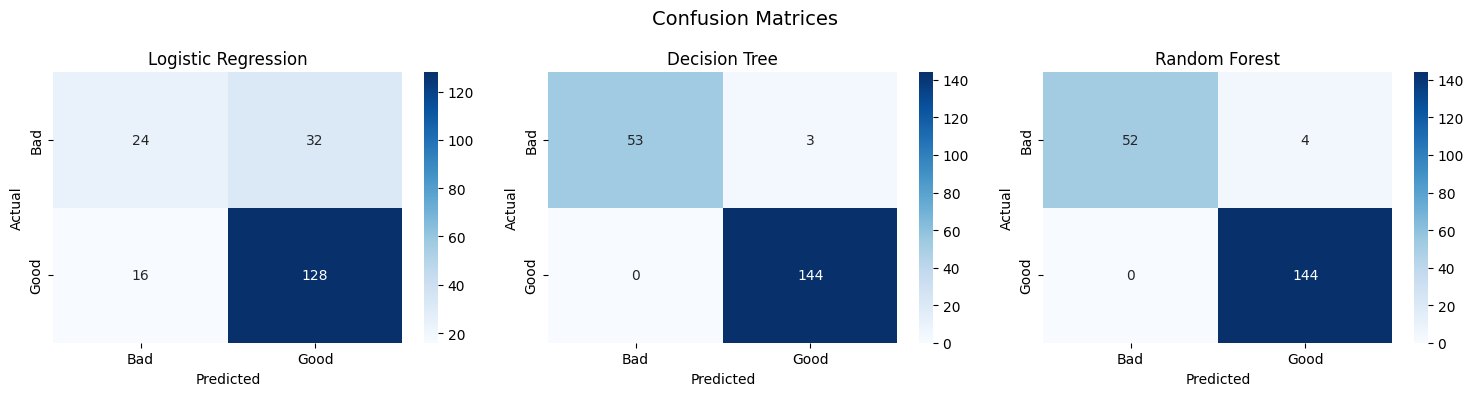

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ("Logistic Regression", lr_pred),
    ("Decision Tree",       dt_pred),
    ("Random Forest",       rf_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bad','Good'],
                yticklabels=['Bad','Good'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

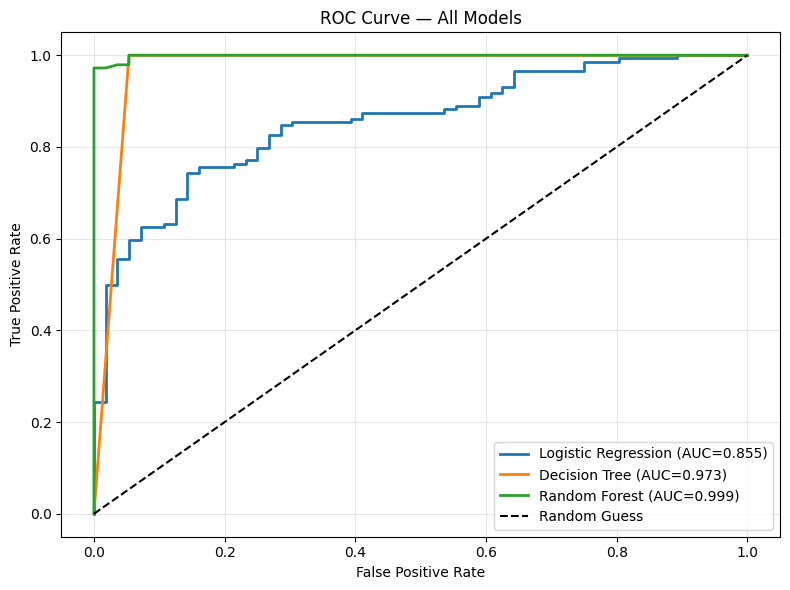

In [13]:
plt.figure(figsize=(8, 6))

for name, prob in [
    ("Logistic Regression", lr_prob),
    ("Decision Tree",       dt_prob),
    ("Random Forest",       rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr,
             label=f'{name} (AUC={auc:.3f})', lw=2)

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

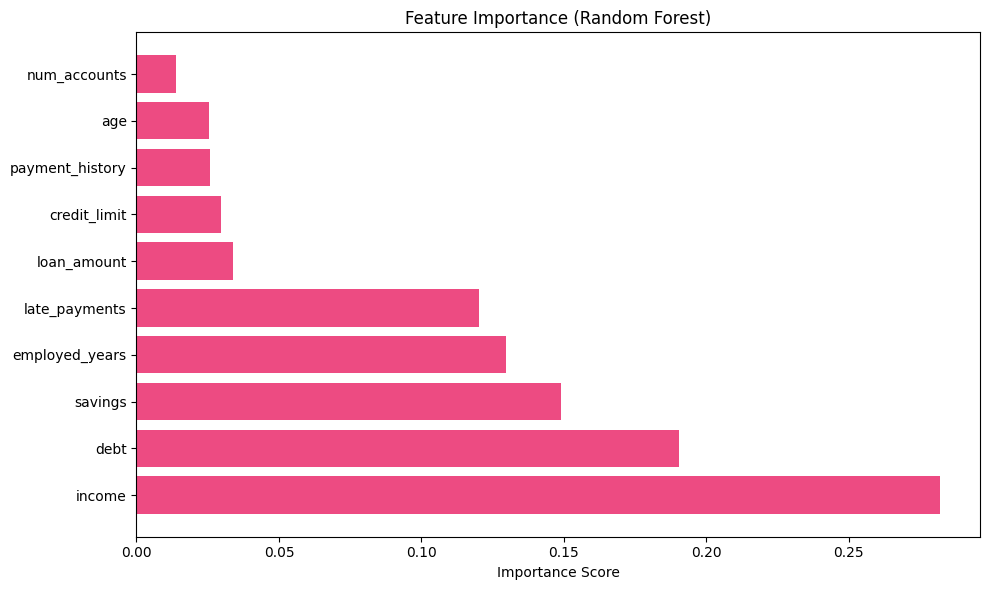


🏆 Top 5 Most Important Features:
  1. income              0.2819
  2. debt                0.1903
  3. savings             0.1491
  4. employed_years      0.1298
  5. late_payments       0.1204


In [14]:
feature_names = list(df.drop('Creditability', axis=1).columns)
importances   = rf.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)),
         importances[indices],
         color='#e91e63', alpha=0.8)
plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Most Important Features:")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]:<20}"
          f"{importances[indices[i]]:.4f}")

In [15]:
results = pd.DataFrame({
    'Model'    : ['Logistic Regression',
                  'Decision Tree',
                  'Random Forest'],
    'Accuracy' : [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, dt_pred),
                  accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred),
                  precision_score(y_test, dt_pred),
                  precision_score(y_test, rf_pred)],
    'Recall'   : [recall_score(y_test, lr_pred),
                  recall_score(y_test, dt_pred),
                  recall_score(y_test, rf_pred)],
    'F1-Score' : [f1_score(y_test, lr_pred),
                  f1_score(y_test, dt_pred),
                  f1_score(y_test, rf_pred)],
    'ROC-AUC'  : [roc_auc_score(y_test, lr_prob),
                  roc_auc_score(y_test, dt_prob),
                  roc_auc_score(y_test, rf_prob)],
}).set_index('Model').round(4)

print("📊 FINAL MODEL COMPARISON:")
print(results.to_string())
print(f"\n🏆 Best Model: {results['ROC-AUC'].idxmax()}")

📊 FINAL MODEL COMPARISON:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.760     0.8000  0.8889    0.8421   0.8549
Decision Tree           0.985     0.9796  1.0000    0.9897   0.9732
Random Forest           0.980     0.9730  1.0000    0.9863   0.9987

🏆 Best Model: Random Forest


In [16]:
new_person = pd.DataFrame([{
    'age'            : 35,
    'income'         : 55000,
    'debt'           : 12000,
    'loan_amount'    : 20000,
    'credit_limit'   : 40000,
    'employed_years' : 8,
    'num_accounts'   : 3,
    'late_payments'  : 1,
    'payment_history': 85,
    'savings'        : 15000
}])

scaled_person = scaler.transform(new_person)
prediction    = rf.predict(scaled_person)[0]
probability   = rf.predict_proba(scaled_person)[0]

print("👤 Person Profile:")
print("   Age            : 35 years")
print("   Income         : ₹55,000")
print("   Debt           : ₹12,000")
print("   Late Payments  : 1")
print("   Savings        : ₹15,000")
print(f"\n🔮 PREDICTION : "
      f"{'✅ GOOD CREDIT' if prediction==1 else '❌ BAD CREDIT'}")
print(f"   Good Credit Probability : {probability[1]*100:.1f}%")
print(f"   Bad Credit Probability  : {probability[0]*100:.1f}%")

👤 Person Profile:
   Age            : 35 years
   Income         : ₹55,000
   Debt           : ₹12,000
   Late Payments  : 1
   Savings        : ₹15,000

🔮 PREDICTION : ✅ GOOD CREDIT
   Good Credit Probability : 99.0%
   Bad Credit Probability  : 1.0%


In [17]:
import joblib

joblib.dump(rf,     'credit_model.pkl')
joblib.dump(scaler, 'credit_scaler.pkl')
print("✅ Model saved!")

from google.colab import files
files.download('credit_model.pkl')
files.download('credit_scaler.pkl')
print("✅ Downloaded to your computer!")

✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded to your computer!
